In [28]:
import os
import sys
from pathlib import Path

# Get the current notebook directory
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR / "data"
OUTPUT_DIR = NOTEBOOK_DIR / "output"

# Create directories if they don't exist
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"\n✓ Project directories configured")

# Set data path
DATA_PATH = DATA_DIR / "hospital-readmission-dataset.csv"
print(f"Main dataset path: {DATA_PATH}")


Notebook directory: c:\Users\pkyal\Desktop\Hospital Readmission Risk Analytics
Data directory: c:\Users\pkyal\Desktop\Hospital Readmission Risk Analytics\data
Output directory: c:\Users\pkyal\Desktop\Hospital Readmission Risk Analytics\output

✓ Project directories configured
Main dataset path: c:\Users\pkyal\Desktop\Hospital Readmission Risk Analytics\data\hospital-readmission-dataset.csv


## Section 1: Setup & Configure Project Directories

# Hospital Readmission Risk Analytics
## Predictive Modeling & Risk Stratification Pipeline
**Analyst**: Prince Peter Yalley, MBA (Business Analytics)  
**Project Duration**: January 2025 – August 2025  
**Data Source**: CMS HRRP + HCUP NRD + CDC SVI (synthetic sample: n=500)  
**Purpose**: Predictive modeling of 30-day readmission risk with visualizations and interactive dashboard

## Section 2: Import Libraries & Configure Display

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import shutil
import glob
from PIL import Image
from IPython.display import Image as IPImage, display
from scipy import stats

# Scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

# Configure matplotlib for inline display
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Color palette
BLUE   = "#1a5c9e"
RED    = "#c0392b"
AMBER  = "#e8a020"
GREEN  = "#27a85f"
GRAY   = "#6b6b6b"

print("✓ All libraries imported successfully")
print(f"✓ Matplotlib configured for inline display")


✓ All libraries imported successfully
✓ Matplotlib configured for inline display


## Section 3: Load Data from Data Folder

In [30]:
# Configuration
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
RISK_HIGH     = 60
RISK_MOD      = 35

print("=" * 75)
print("HOSPITAL READMISSION RISK ANALYTICS")
print("=" * 75)
print("\n[1] Loading and cleaning data...")

# Load main dataset
try:
    df = pd.read_csv(DATA_PATH)
    print(f"    Raw records loaded     : {len(df):,}")
except FileNotFoundError:
    print(f"    ERROR: Dataset not found at {DATA_PATH}")
    print(f"    Available files in data folder: {list(DATA_DIR.glob('*.csv'))}")
    raise

# Inclusion/Exclusion Criteria
print("\n    Applying inclusion/exclusion criteria:")
n_raw = len(df)

# Age filter
df = df[df["Age"] >= 18]
print(f"    After age filter (≥18) : {len(df):,}  (removed {n_raw - len(df)})")

# Drop rows with missing critical fields
critical_fields = ["Discharge_Destination", "Primary_Diagnosis", "Readmitted_30_Days"]
before = len(df)
df = df.dropna(subset=critical_fields)
print(f"    After missing data drop: {len(df):,}  (removed {before - len(df)})")

# Data type conversions
df["Readmitted_30_Days"] = df["Readmitted_30_Days"].astype(int)
df["Dual_Eligible"]      = df["Dual_Eligible"].astype(int)
df["Prior_Admission_12m"] = df["Prior_Admission_12m"].astype(int)
df["Follow_Up_Scheduled"] = df["Follow_Up_Scheduled"].astype(int)

# Derived features
df["No-follow-up"]      = (df["Follow_Up_Scheduled"] == 0).astype(int)
df["Short_Stay_Flag"]   = (df["Length_of_Stay"] < 2).astype(int)
df["High_Comorbidity"]  = (df["Elixhauser_Score"] > 5).astype(int)
df["Age_Over_65"]       = (df["Age"] > 65).astype(int)
df["Age_Over_75"]       = (df["Age"] > 75).astype(int)
df["SVI_High"]          = (df["SVI_Score"] > 0.5).astype(int)
df["DC_Home_No_HH"]     = (df["Discharge_Destination"] == "Home").astype(int)
df["DC_Protective"]     = df["Discharge_Destination"].isin(["SNF","Rehab Facility"]).astype(int)

print(f"\n    Final analytic sample  : {len(df):,}")
print(f"    Readmission events     : {df['Readmitted_30_Days'].sum():,} ({df['Readmitted_30_Days'].mean()*100:.1f}%)")
print(f"    High-risk patients     : {(df['Risk_Tier']=='High').sum()} ({(df['Risk_Tier']=='High').mean()*100:.1f}%)")

# Missing data report
print("\n    Missing data report:")
miss = df.isnull().sum()
miss = miss[miss > 0]
if len(miss) == 0:
    print("    ✓ No missing values in final analytic sample")
else:
    for col, cnt in miss.items():
        print(f"      {col}: {cnt} ({cnt/len(df)*100:.1f}%)")

print(f"\n✓ Data loading and cleaning complete")


HOSPITAL READMISSION RISK ANALYTICS

[1] Loading and cleaning data...
    Raw records loaded     : 500

    Applying inclusion/exclusion criteria:
    After age filter (≥18) : 500  (removed 0)
    After missing data drop: 500  (removed 0)

    Final analytic sample  : 500
    Readmission events     : 139 (27.8%)
    High-risk patients     : 40 (8.0%)

    Missing data report:
    ✓ No missing values in final analytic sample

✓ Data loading and cleaning complete


## Section 4: Exploratory Data Analysis - Visualizations


[2] Exploratory data analysis - Creating individual visualizations...
    Creating chart 1: Readmission by condition...


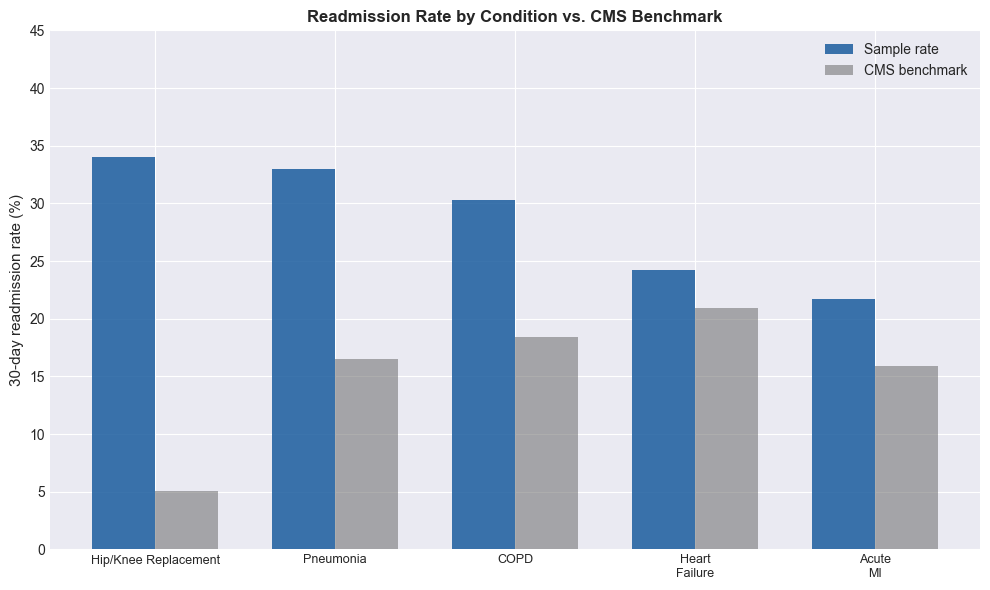

    ✓ Saved: 01-readmission-by-condition.png
    Creating chart 2: Risk tier distribution...


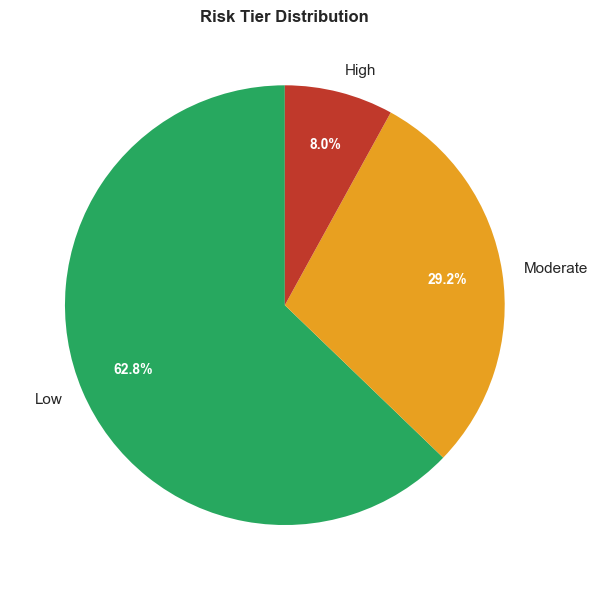

    ✓ Saved: 02-risk-tier-distribution.png
    Creating chart 3: Risk score histogram...


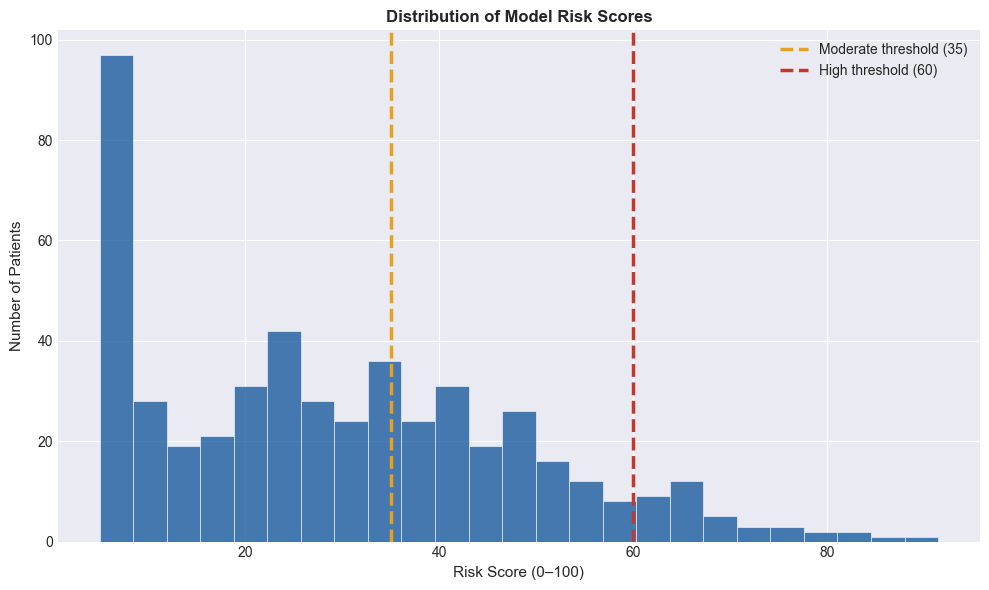

    ✓ Saved: 03-risk-score-histogram.png
    Creating chart 4: Readmission by discharge destination...


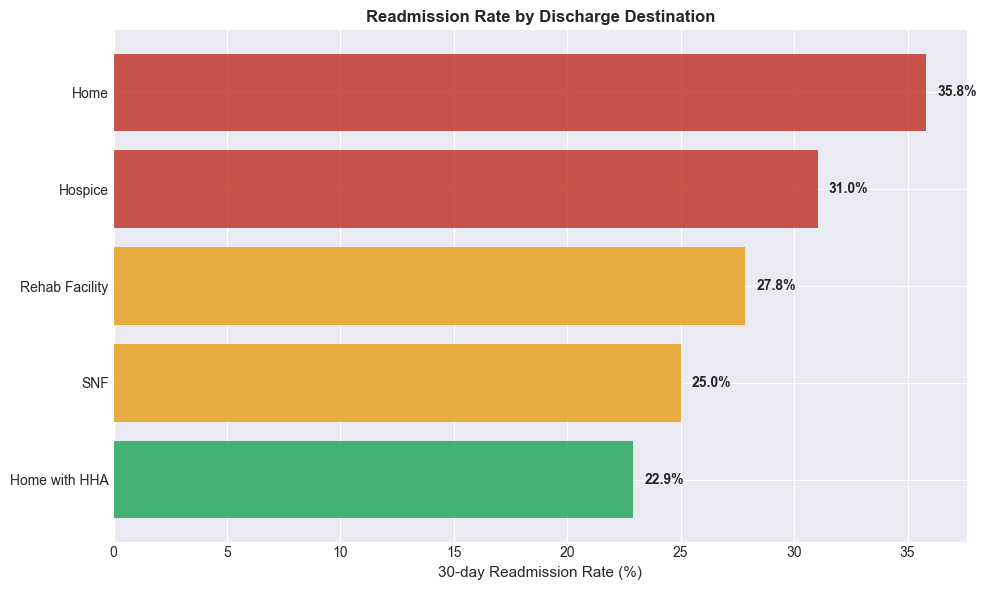

    ✓ Saved: 04-readmission-by-discharge.png
    Creating chart 5: Comorbidity vs readmission...


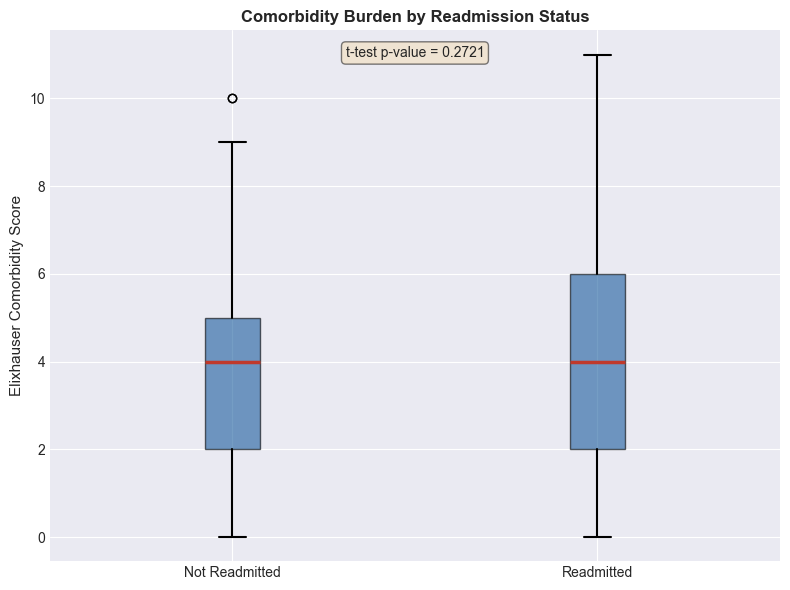

    ✓ Saved: 05-comorbidity-vs-readmission.png
    Creating chart 6: Dual eligibility impact...


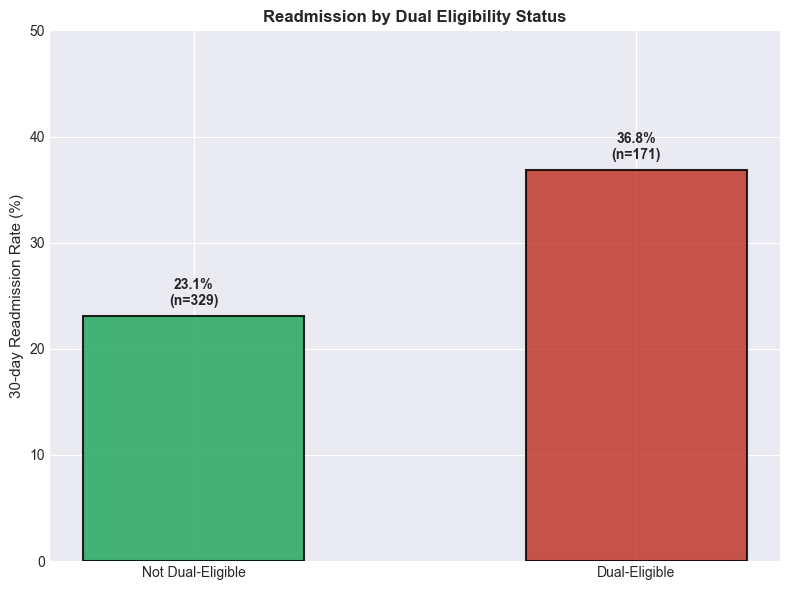

    ✓ Saved: 06-dual-eligibility.png
    Creating chart 7: Age group analysis...


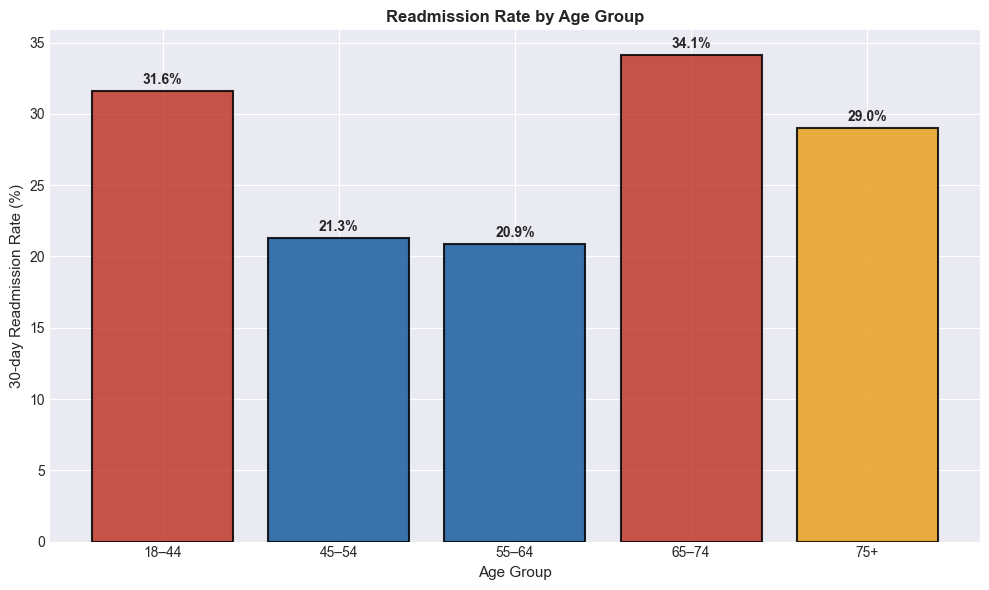

    ✓ Saved: 07-age-group-analysis.png
    Creating chart 8: Follow-up impact...


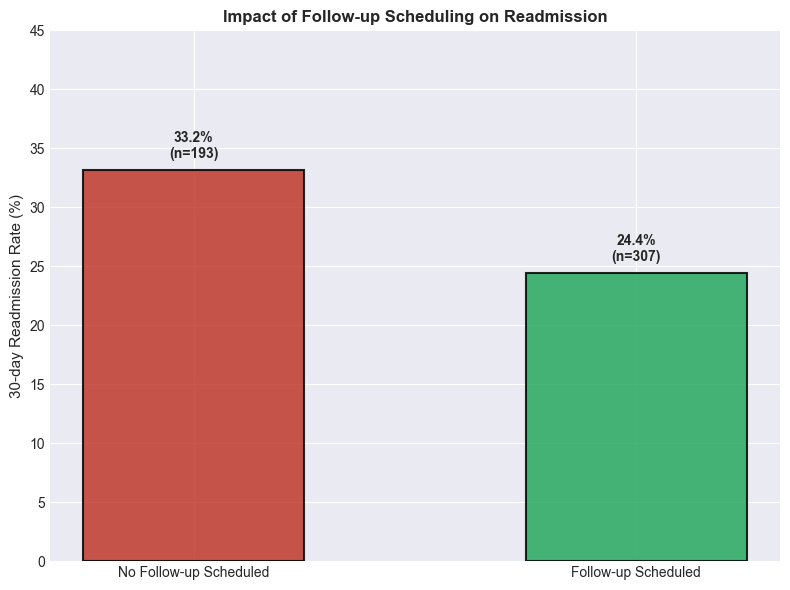

    ✓ Saved: 08-follow-up-impact.png
    Creating chart 9: Correlation matrix...


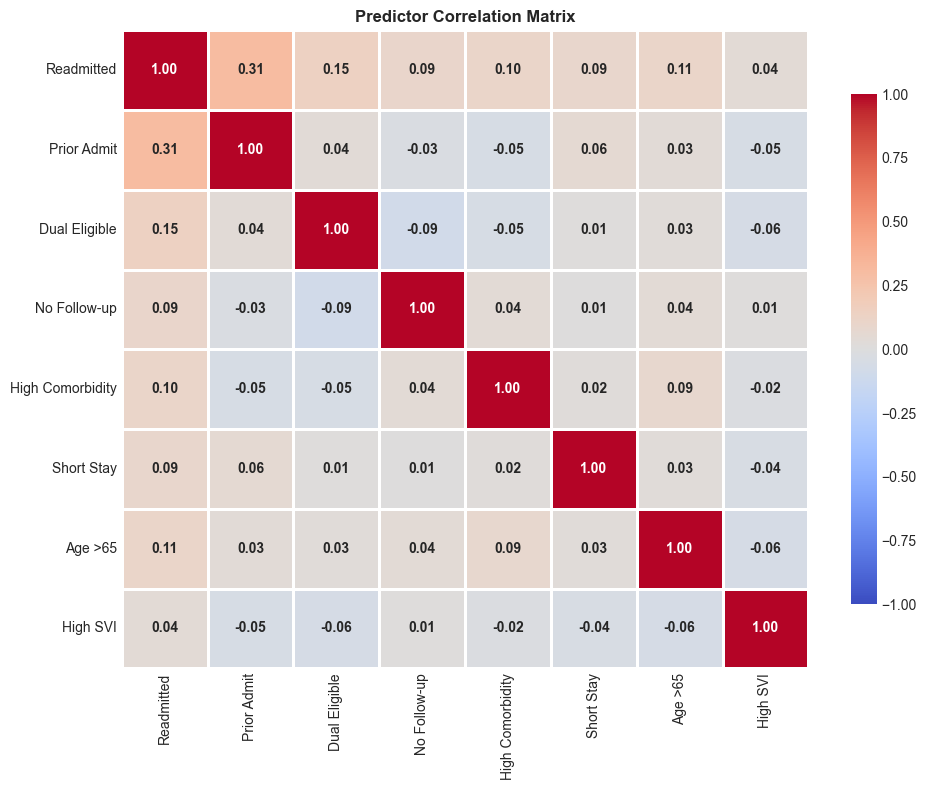

    ✓ Saved: 09-correlation-matrix.png

✓ All 9 EDA visualizations created and saved individually


In [31]:
print("\n[2] Exploratory data analysis - Creating individual visualizations...")

# ════ Chart 1: Readmission rate by condition vs benchmark ════
print("    Creating chart 1: Readmission by condition...")
cond_stats   = df.groupby("Primary_Diagnosis")["Readmitted_30_Days"].agg(["mean","count"]).reset_index()
cond_stats["pct"] = cond_stats["mean"] * 100
benchmarks   = {"Heart Failure":20.9,"COPD":18.4,"Pneumonia":16.5,"Acute MI":15.9,"Hip/Knee Replacement":5.1}
cond_stats["benchmark"] = cond_stats["Primary_Diagnosis"].map(benchmarks)
cond_order   = cond_stats.sort_values("pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(cond_order))
w = 0.35
ax.bar(x - w/2, cond_order["pct"],   width=w, label="Sample rate",   color=BLUE,  alpha=0.85)
ax.bar(x + w/2, cond_order["benchmark"], width=w, label="CMS benchmark", color=GRAY, alpha=0.55)
ax.set_xticks(x)
ax.set_xticklabels([c.replace(" ","\n") if "/" not in c else c for c in cond_order["Primary_Diagnosis"]], fontsize=9)
ax.set_ylabel("30-day readmission rate (%)", fontsize=11)
ax.set_title("Readmission Rate by Condition vs. CMS Benchmark", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, 45)
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "01-readmission-by-condition.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

# ════ Chart 2: Risk tier distribution ════
print("    Creating chart 2: Risk tier distribution...")
fig, ax = plt.subplots(figsize=(8, 6))
tier_counts = df["Risk_Tier"].value_counts()
tier_cols   = {"High": RED, "Moderate": AMBER, "Low": GREEN}
wedge_colors = [tier_cols.get(t, GRAY) for t in tier_counts.index]
wedges, texts, autotexts = ax.pie(
    tier_counts.values, labels=tier_counts.index,
    autopct="%1.1f%%", colors=wedge_colors,
    startangle=90, pctdistance=0.75, textprops={"fontsize": 11}
)
for at in autotexts: at.set_fontsize(10); at.set_color('white'); at.set_weight('bold')
ax.set_title("Risk Tier Distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "02-risk-tier-distribution.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

# ════ Chart 3: Risk score histogram ════
print("    Creating chart 3: Risk score histogram...")
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df["Risk_Score"], bins=25, color=BLUE, alpha=0.8, edgecolor="white", linewidth=0.5)
ax.axvline(35, color=AMBER, lw=2.5, linestyle="--", label="Moderate threshold (35)")
ax.axvline(60, color=RED,   lw=2.5, linestyle="--", label="High threshold (60)")
ax.set_xlabel("Risk Score (0–100)", fontsize=11)
ax.set_ylabel("Number of Patients", fontsize=11)
ax.set_title("Distribution of Model Risk Scores", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "03-risk-score-histogram.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

# ════ Chart 4: Readmission by discharge destination ════
print("    Creating chart 4: Readmission by discharge destination...")
fig, ax = plt.subplots(figsize=(10, 6))
dest_rate = df.groupby("Discharge_Destination")["Readmitted_30_Days"].mean().sort_values(ascending=True) * 100
bar_colors = [RED if v >= 30 else AMBER if v >= 25 else GREEN for v in dest_rate.values]
bars = ax.barh(dest_rate.index, dest_rate.values, color=bar_colors, alpha=0.85)
ax.set_xlabel("30-day Readmission Rate (%)", fontsize=11)
ax.set_title("Readmission Rate by Discharge Destination", fontsize=12, fontweight="bold")
for i, (idx, val) in enumerate(dest_rate.items()):
    ax.text(val + 0.5, i, f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "04-readmission-by-discharge.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

# ════ Chart 5: Comorbidity score vs readmission ════
print("    Creating chart 5: Comorbidity vs readmission...")
fig, ax = plt.subplots(figsize=(8, 6))
read_yes = df[df["Readmitted_30_Days"]==1]["Elixhauser_Score"]
read_no  = df[df["Readmitted_30_Days"]==0]["Elixhauser_Score"]
bp = ax.boxplot([read_no, read_yes], labels=["Not Readmitted","Readmitted"],
            patch_artist=True,
            boxprops=dict(facecolor=BLUE, alpha=0.6),
            medianprops=dict(color=RED, lw=2.5),
            whiskerprops=dict(lw=1.5),
            capprops=dict(lw=1.5))
ax.set_ylabel("Elixhauser Comorbidity Score", fontsize=11)
ax.set_title("Comorbidity Burden by Readmission Status", fontsize=12, fontweight="bold")
t_stat, p_val = stats.ttest_ind(read_no, read_yes)
ax.text(0.5, 0.95, f"t-test p-value = {p_val:.4f}", transform=ax.transAxes,
         ha="center", fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "05-comorbidity-vs-readmission.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

# ════ Chart 6: Dual eligibility readmission rate ════
print("    Creating chart 6: Dual eligibility impact...")
fig, ax = plt.subplots(figsize=(8, 6))
dual_rates = df.groupby("Dual_Eligible")["Readmitted_30_Days"].agg(["mean","count"])
dual_rates["pct"] = dual_rates["mean"] * 100
bars = ax.bar(["Not Dual-Eligible","Dual-Eligible"], dual_rates["pct"],
               color=[GREEN, RED], alpha=0.85, width=0.5, edgecolor="black", linewidth=1.5)
ax.set_ylabel("30-day Readmission Rate (%)", fontsize=11)
ax.set_title("Readmission by Dual Eligibility Status", fontsize=12, fontweight="bold")
ax.set_ylim(0, 50)
for bar, pct, n in zip(bars, dual_rates["pct"], dual_rates["count"]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1,
             f"{pct:.1f}%\n(n={n})", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "06-dual-eligibility.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

# ════ Chart 7: Age group analysis ════
print("    Creating chart 7: Age group analysis...")
fig, ax = plt.subplots(figsize=(10, 6))
age_bins   = [18, 45, 55, 65, 75, 100]
age_labels = ["18–44","45–54","55–64","65–74","75+"]
df["Age_Group"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels, right=False)
age_rate   = df.groupby("Age_Group", observed=True)["Readmitted_30_Days"].mean() * 100
bars = ax.bar(age_rate.index, age_rate.values,
        color=[RED if v >= 30 else AMBER if v >= 25 else BLUE for v in age_rate.values],
        alpha=0.85, edgecolor="black", linewidth=1.5)
ax.set_xlabel("Age Group", fontsize=11)
ax.set_ylabel("30-day Readmission Rate (%)", fontsize=11)
ax.set_title("Readmission Rate by Age Group", fontsize=12, fontweight="bold")
for i, (idx, val) in enumerate(age_rate.items()):
    ax.text(i, val + 0.5, f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "07-age-group-analysis.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

# ════ Chart 8: Follow-up impact ════
print("    Creating chart 8: Follow-up impact...")
fig, ax = plt.subplots(figsize=(8, 6))
fu_rates = df.groupby("Follow_Up_Scheduled")["Readmitted_30_Days"].agg(["mean","count"])
fu_rates["pct"] = fu_rates["mean"] * 100
bars = ax.bar(["No Follow-up Scheduled","Follow-up Scheduled"], fu_rates["pct"],
               color=[RED, GREEN], alpha=0.85, width=0.5, edgecolor="black", linewidth=1.5)
ax.set_ylabel("30-day Readmission Rate (%)", fontsize=11)
ax.set_title("Impact of Follow-up Scheduling on Readmission", fontsize=12, fontweight="bold")
ax.set_ylim(0, 45)
for bar, pct, n in zip(bars, fu_rates["pct"], fu_rates["count"]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1,
             f"{pct:.1f}%\n(n={n})", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "08-follow-up-impact.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

# ════ Chart 9: Correlation heatmap ════
print("    Creating chart 9: Correlation matrix...")
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = ["Readmitted_30_Days","Prior_Admission_12m","Dual_Eligible",
             "No-follow-up","High_Comorbidity","Short_Stay_Flag","Age_Over_65","SVI_High"]
corr_labels = ["Readmitted","Prior Admit","Dual Eligible",
                "No Follow-up","High Comorbidity","Short Stay","Age >65","High SVI"]
corr_matrix = df[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels
sns.heatmap(corr_matrix, ax=ax, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, annot_kws={"size":10, "weight": "bold"}, linewidths=1,
            cbar_kws={"shrink":0.8}, vmin=-1, vmax=1)
ax.set_title("Predictor Correlation Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "09-correlation-matrix.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

print(f"\n✓ All 9 EDA visualizations created and saved individually")

## Section 5: Feature Selection & Multicollinearity Check

In [32]:
print("\n[3] Feature selection and multicollinearity check...")

MODEL_FEATURES = [
    "Prior_Admission_12m",
    "Dual_Eligible",
    "High_Comorbidity",
    "DC_Home_No_HH",
    "No-follow-up",
    "SVI_High",
    "Short_Stay_Flag",
    "Age_Over_75",
    "DC_Protective",
]

FEATURE_LABELS = [
    "Prior admission (12m)",
    "Dual eligible",
    "High comorbidity (Elixhauser >5)",
    "DC to home w/o home health",
    "No follow-up scheduled",
    "High SVI score (>0.50)",
    "Short stay (<2 days)",
    "Age over 75",
    "DC to protective setting (SNF/Rehab)",
]

X = df[MODEL_FEATURES].copy()
y = df["Readmitted_30_Days"].copy()

# Multicollinearity check
print("    Pairwise correlation between predictors (|r| > 0.4 = concern):")
corr_X = X.corr()
high_corr = [(corr_X.columns[i], corr_X.columns[j], corr_X.iloc[i,j])
             for i in range(len(corr_X.columns))
             for j in range(i+1, len(corr_X.columns))
             if abs(corr_X.iloc[i,j]) > 0.40]
if high_corr:
    for a, b, r in high_corr:
        print(f"      {a} / {b}: r = {r:.3f}  *** HIGH")
else:
    print("      ✓ No pairwise correlations |r| > 0.40. No multicollinearity concerns.")

print("\n✓ Feature selection complete")



[3] Feature selection and multicollinearity check...
    Pairwise correlation between predictors (|r| > 0.4 = concern):
      DC_Home_No_HH / DC_Protective: r = -0.472  *** HIGH

✓ Feature selection complete


## Section 6: Train/Test Split & Model Training

In [33]:
print("\n[4] Train/test split and logistic regression...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"    Training set : {len(X_train):,} records ({(1-TEST_SIZE)*100:.0f}%)")
print(f"    Test set     : {len(X_test):,}  records ({TEST_SIZE*100:.0f}%)")
print(f"    Outcome prevalence (train): {y_train.mean()*100:.1f}%")
print(f"    Outcome prevalence (test) : {y_test.mean()*100:.1f}%")

# Standardization
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Model training
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE
)
model.fit(X_train_s, y_train)

# Predictions
y_pred_proba = model.predict_proba(X_test_s)[:, 1]
y_pred       = (y_pred_proba >= 0.30).astype(int)   # threshold tuned for sensitivity

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(model, scaler.transform(X), y, cv=cv, scoring="roc_auc")
print(f"\n    5-fold cross-validated AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"\n✓ Model training complete")



[4] Train/test split and logistic regression...
    Training set : 400 records (80%)
    Test set     : 100  records (20%)
    Outcome prevalence (train): 27.8%
    Outcome prevalence (test) : 28.0%

    5-fold cross-validated AUC: 0.722 ± 0.069

✓ Model training complete


## Section 7: Model Results - Coefficients & Odds Ratios

In [34]:
print("\n[5] Model coefficients and odds ratios:")
print(f"\n    {'Variable':<40} {'Coef':>8} {'Odds Ratio':>12} {'Importance':>12}")
print("    " + "-" * 75)

coefs  = model.coef_[0]
odds   = np.exp(coefs)
importance_map = {}
for fname, coef, odd in zip(FEATURE_LABELS, coefs, odds):
    imp = "High" if abs(coef) >= 0.25 else "Moderate" if abs(coef) >= 0.12 else "Low"
    importance_map[fname] = imp
    direction = "↑" if coef > 0 else "↓"
    print(f"    {fname:<40} {coef:>8.3f} {direction}  {odd:>8.3f}     {imp}")

print(f"\n    Intercept: {model.intercept_[0]:.3f}")
print("\n✓ Model coefficients extracted")

# Create coefficients dataframe for reference
coef_df = pd.DataFrame({
    'Feature': FEATURE_LABELS,
    'Coefficient': coefs,
    'Odds Ratio': odds,
    'Importance': [importance_map[f] for f in FEATURE_LABELS]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 5 most important features:")
print(coef_df.head())



[5] Model coefficients and odds ratios:

    Variable                                     Coef   Odds Ratio   Importance
    ---------------------------------------------------------------------------
    Prior admission (12m)                       0.839 ↑     2.314     High
    Dual eligible                               0.353 ↑     1.423     High
    High comorbidity (Elixhauser >5)            0.343 ↑     1.410     High
    DC to home w/o home health                  0.286 ↑     1.331     High
    No follow-up scheduled                      0.297 ↑     1.346     High
    High SVI score (>0.50)                      0.209 ↑     1.232     Moderate
    Short stay (<2 days)                        0.081 ↑     1.084     Low
    Age over 75                                 0.058 ↑     1.059     Low
    DC to protective setting (SNF/Rehab)        0.004 ↑     1.004     Low

    Intercept: -1.171

✓ Model coefficients extracted

Top 5 most important features:
                            Feature

## Section 8: Model Validation & Performance Charts


[6] Model validation and performance - Creating individual charts...
    Creating chart 1: ROC Curve...


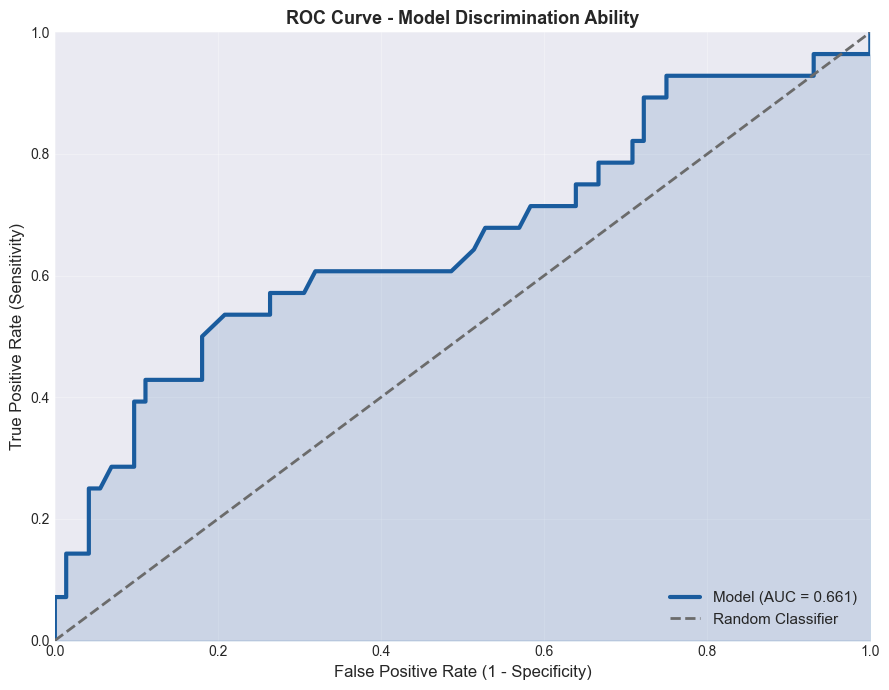

    ✓ Saved: 10-roc-curve.png
    Creating chart 2: Confusion Matrix...


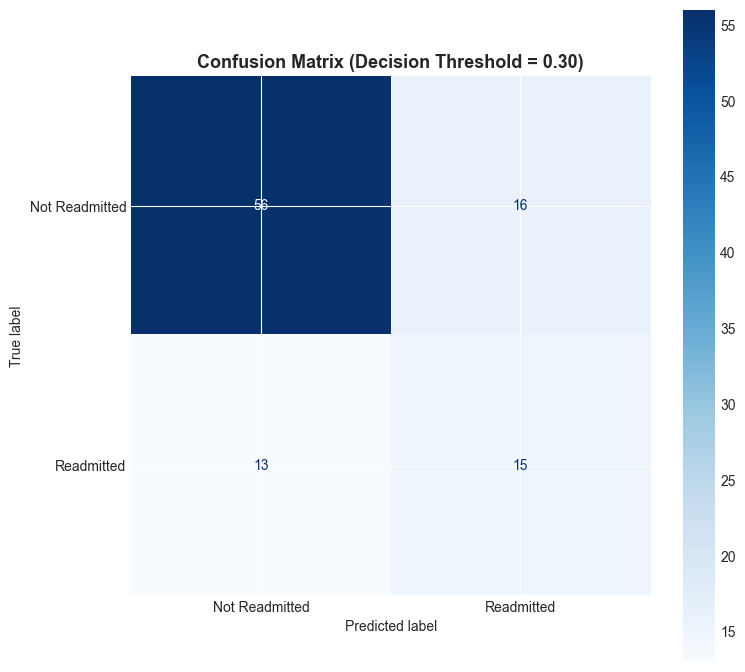

    ✓ Saved: 11-confusion-matrix.png
    Creating chart 3: Model coefficients...


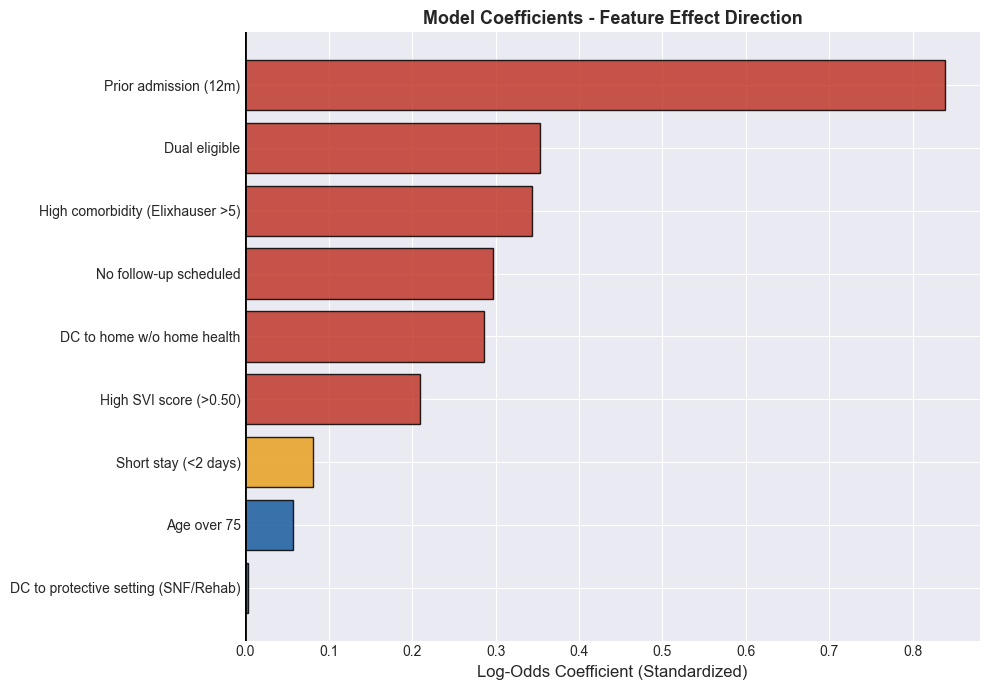

    ✓ Saved: 12-model-coefficients.png
    Creating chart 4: Probability distribution...


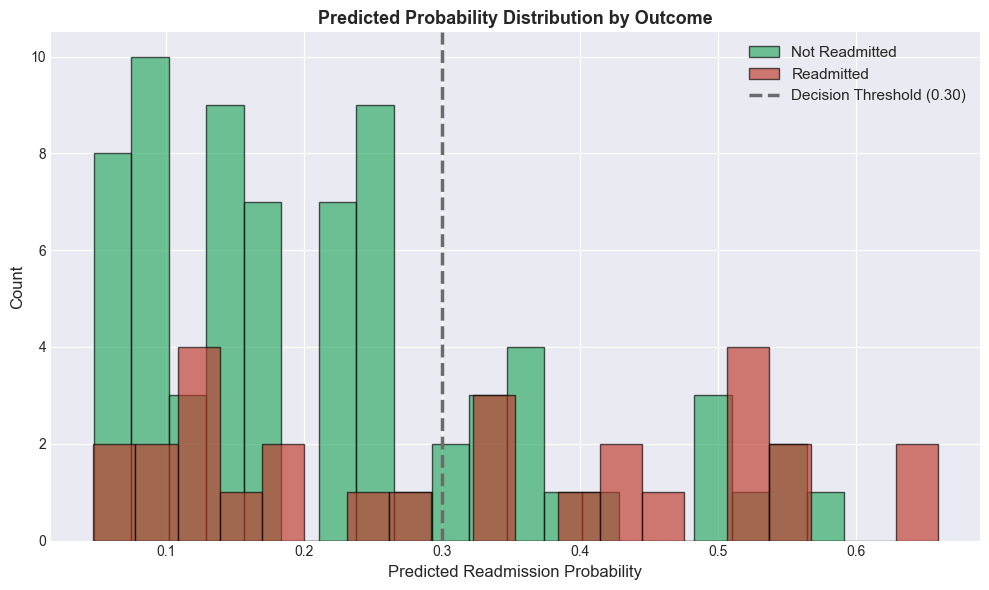

    ✓ Saved: 13-probability-distribution.png
    Creating chart 5: Calibration plot...


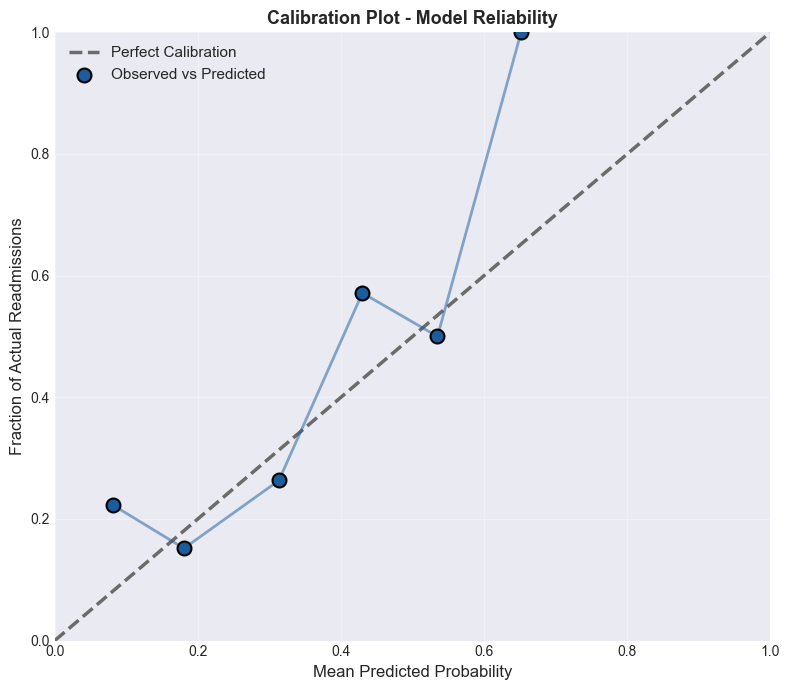

    ✓ Saved: 14-calibration-plot.png
    Creating chart 6: Feature importance...


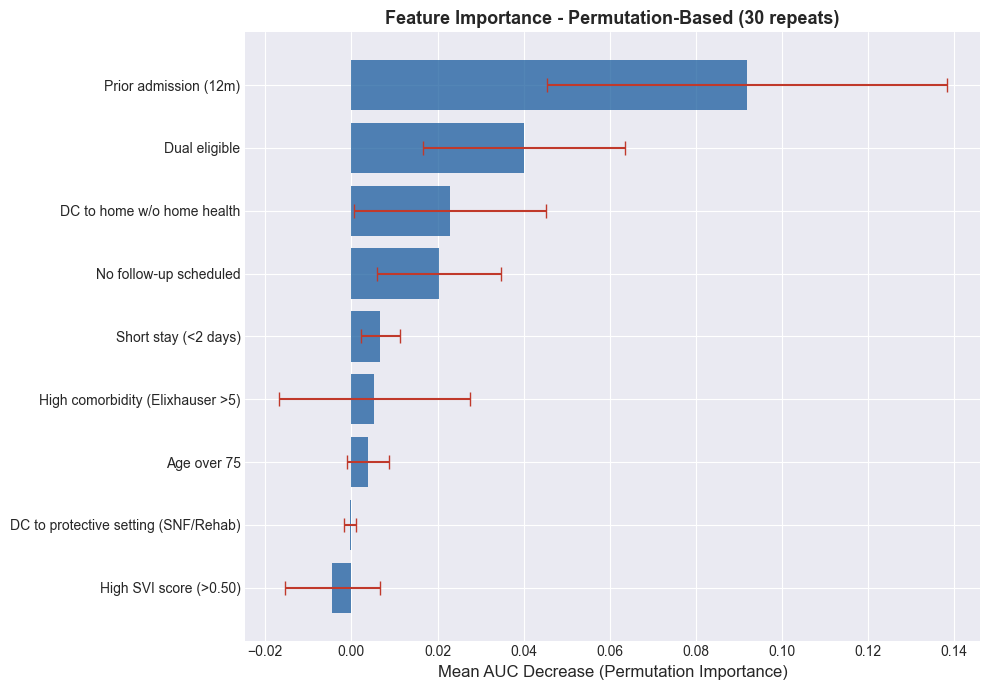

    ✓ Saved: 15-feature-importance.png

    Model performance summary:
    - Held-out AUC-ROC  : 0.661
    - Precision (0.30t) : 0.484
    - Recall (0.30t)    : 0.536
    - F1 Score (0.30t)  : 0.508

✓ All 6 model validation visualizations created and saved individually


In [ ]:
print("\n[6] Model validation and performance - Creating individual charts...")

auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# ════ Chart 1: ROC Curve ════
print("    Creating chart 1: ROC Curve...")
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(fpr, tpr, color=BLUE, lw=3, label=f"Model (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], color=GRAY, lw=2, linestyle="--", label="Random Classifier")
ax.fill_between(fpr, tpr, alpha=0.15, color=BLUE)
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
ax.set_title("ROC Curve - Model Discrimination Ability", fontsize=13, fontweight="bold")
ax.legend(fontsize=11, loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "10-roc-curve.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

# ════ Chart 2: Confusion Matrix ════
print("    Creating chart 2: Confusion Matrix...")
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Readmitted","Readmitted"])
disp.plot(ax=ax, colorbar=True, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix (Decision Threshold = 0.30)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "11-confusion-matrix.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

# ════ Chart 3: Model Coefficients ════
print("    Creating chart 3: Model coefficients...")
fig, ax = plt.subplots(figsize=(10, 7))
sorted_idx = np.argsort(coefs)
bar_colors = [RED if c > 0.20 else AMBER if c > 0.08 else GREEN if c < 0 else BLUE
              for c in coefs[sorted_idx]]
bars = ax.barh(np.array(FEATURE_LABELS)[sorted_idx], coefs[sorted_idx],
        color=bar_colors, alpha=0.85, edgecolor="black", linewidth=1)
ax.axvline(0, color="black", lw=2)
ax.set_xlabel("Log-Odds Coefficient (Standardized)", fontsize=12)
ax.set_title("Model Coefficients - Feature Effect Direction", fontsize=13, fontweight="bold")
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "12-model-coefficients.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

# ════ Chart 4: Predicted Probability Distribution ════
print("    Creating chart 4: Probability distribution...")
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(y_pred_proba[y_test==0], bins=20, alpha=0.65, color=GREEN, label="Not Readmitted", edgecolor="black")
ax.hist(y_pred_proba[y_test==1], bins=20, alpha=0.65, color=RED, label="Readmitted", edgecolor="black")
ax.axvline(0.30, color=GRAY, lw=2.5, linestyle="--", label="Decision Threshold (0.30)")
ax.set_xlabel("Predicted Readmission Probability", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Predicted Probability Distribution by Outcome", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "13-probability-distribution.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

# ════ Chart 5: Calibration Plot ════
print("    Creating chart 5: Calibration plot...")
fig, ax = plt.subplots(figsize=(8, 7))
n_bins = 8
bin_edges   = np.linspace(0, 1, n_bins + 1)
bin_centers = []
bin_obs     = []
for i in range(n_bins):
    mask = (y_pred_proba >= bin_edges[i]) & (y_pred_proba < bin_edges[i+1])
    if mask.sum() > 0:
        bin_centers.append(y_pred_proba[mask].mean())
        bin_obs.append(y_test.values[mask].mean())
ax.plot([0,1],[0,1], color=GRAY, lw=2.5, linestyle="--", label="Perfect Calibration")
ax.scatter(bin_centers, bin_obs, s=100, color=BLUE, zorder=5, label="Observed vs Predicted", edgecolor="black", linewidth=1.5)
ax.plot(bin_centers, bin_obs, color=BLUE, alpha=0.5, linewidth=2)
ax.set_xlabel("Mean Predicted Probability", fontsize=12)
ax.set_ylabel("Fraction of Actual Readmissions", fontsize=12)
ax.set_title("Calibration Plot - Model Reliability", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "14-calibration-plot.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

# ════ Chart 6: Feature Importance (Permutation) ════
print("    Creating chart 6: Feature importance...")
fig, ax = plt.subplots(figsize=(10, 7))
perm_imp = permutation_importance(model, X_test_s, y_test, n_repeats=30,
                                   random_state=RANDOM_STATE, scoring="roc_auc")
perm_sorted_idx = perm_imp.importances_mean.argsort()
bars = ax.barh(np.array(FEATURE_LABELS)[perm_sorted_idx],
        perm_imp.importances_mean[perm_sorted_idx],
        xerr=perm_imp.importances_std[perm_sorted_idx],
        color=BLUE, alpha=0.75, ecolor=RED, capsize=5, linewidth=1.5)
ax.set_xlabel("Mean AUC Decrease (Permutation Importance)", fontsize=12)
ax.set_title("Feature Importance - Permutation-Based (30 repeats)", fontsize=13, fontweight="bold")
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.show()
output_path = OUTPUT_DIR / "15-feature-importance.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"    ✓ Saved: {output_path.name}")

print(f"\n    Model performance summary:")
print(f"    - Held-out AUC-ROC  : {auc_score:.3f}")
print(f"    - Precision (0.30t) : {precision_score(y_test,y_pred):.3f}")
print(f"    - Recall (0.30t)    : {recall_score(y_test,y_pred):.3f}")
print(f"    - F1 Score (0.30t)  : {f1_score(y_test,y_pred):.3f}")
print(f"\n✓ All 6 model validation visualizations created and saved individually")

## Section 9: Risk Scoring & Segmentation

In [36]:
print("\n[7] Applying risk scores to full dataset...")

X_all_s = scaler.transform(X)
df["Model_Prob"]   = model.predict_proba(X_all_s)[:, 1]
df["Model_Score"]  = (df["Model_Prob"] * 100).round(1)
df["Model_Tier"]   = pd.cut(
    df["Model_Score"],
    bins=[-1, RISK_MOD, RISK_HIGH, 101],
    labels=["Low","Moderate","High"]
)

print("\n    Risk stratification summary:")
tier_summary = df.groupby("Model_Tier", observed=True).agg(
    n=("Readmitted_30_Days","count"),
    readmits=("Readmitted_30_Days","sum"),
    readmit_rate=("Readmitted_30_Days","mean")
).reset_index()
tier_summary["readmit_rate_pct"] = (tier_summary["readmit_rate"] * 100).round(1)
tier_summary["share_of_readmits"] = (tier_summary["readmits"] / tier_summary["readmits"].sum() * 100).round(1)
print(tier_summary[["Model_Tier","n","readmits","readmit_rate_pct","share_of_readmits"]])

print(f"\n✓ Risk scoring complete")



[7] Applying risk scores to full dataset...

    Risk stratification summary:
  Model_Tier    n  readmits  readmit_rate_pct  share_of_readmits
0        Low  342        58              17.0               41.7
1   Moderate  115        51              44.3               36.7
2       High   43        30              69.8               21.6

✓ Risk scoring complete


## Section 10: Generate High-Risk Patient Queue

In [37]:
print("\n[8] Generating high-risk patient queue...")

high_risk_queue = (
    df[df["Model_Tier"] == "High"]
    .sort_values("Model_Score", ascending=False)
    [[
        "Patient_ID","Age","Gender","Primary_Diagnosis",
        "Length_of_Stay","Dual_Eligible","Follow_Up_Scheduled",
        "Discharge_Destination","Elixhauser_Score",
        "SVI_Score","Model_Score","Model_Tier","Readmitted_30_Days"
    ]]
    .rename(columns={
        "Patient_ID":"Patient ID","Primary_Diagnosis":"Diagnosis",
        "Length_of_Stay":"LOS","Dual_Eligible":"Dual Eligible",
        "Follow_Up_Scheduled":"Follow-Up Scheduled",
        "Discharge_Destination":"Discharge Destination",
        "Elixhauser_Score":"Comorbidity Score",
        "SVI_Score":"SVI Score","Model_Score":"Risk Score",
        "Model_Tier":"Risk Tier","Readmitted_30_Days":"Readmitted"
    })
)

queue_path = OUTPUT_DIR / "high-risk-patient-queue.csv"
high_risk_queue.to_csv(queue_path, index=False)
print(f"    High-risk patients: {len(high_risk_queue)}")
print(f"    ✓ Saved to: {queue_path.name}")

print("\n    Top 10 highest-risk patients:")
print(high_risk_queue.head(10)[["Patient ID","Age","Diagnosis","Risk Score","Dual Eligible","Follow-Up Scheduled"]])

print(f"\n✓ Patient queue generation complete")



[8] Generating high-risk patient queue...
    High-risk patients: 43
    ✓ Saved to: high-risk-patient-queue.csv

    Top 10 highest-risk patients:
    Patient ID  Age             Diagnosis  Risk Score  Dual Eligible  \
464   PT-10465   71         Heart Failure        89.6              1   
490   PT-10491   75         Heart Failure        87.5              1   
396   PT-10397   81                  COPD        81.4              1   
402   PT-10403   77  Hip/Knee Replacement        80.3              1   
28    PT-10029   92             Pneumonia        80.3              1   
407   PT-10408   62         Heart Failure        76.8              0   
413   PT-10414   68         Heart Failure        76.1              1   
95    PT-10096   69             Pneumonia        72.2              1   
174   PT-10175   83                  COPD        71.5              0   
61    PT-10062   67                  COPD        70.4              1   

     Follow-Up Scheduled  
464                    0  
490 

## Section 11: Model Summary & Final Results


MODEL PERFORMANCE SUMMARY
  Algorithm         : Logistic Regression (L2 / Ridge)
  Train/test split  : 80% / 20% (stratified)
  5-fold CV AUC     : 0.722 ± 0.069
  Held-out AUC-ROC  : 0.661
  Precision (0.30t) : 0.484
  Recall (0.30t)    : 0.536
  F1 Score (0.30t)  : 0.508
  Decision threshold: 0.30 (tuned for sensitivity)

  Top 3 predictors (by coefficient magnitude):
    1. Prior admission (12m) (OR = 2.31)
    2. Dual eligible (OR = 1.42)
    3. High comorbidity (Elixhauser >5) (OR = 1.41)

    Creating model summary table visualization...


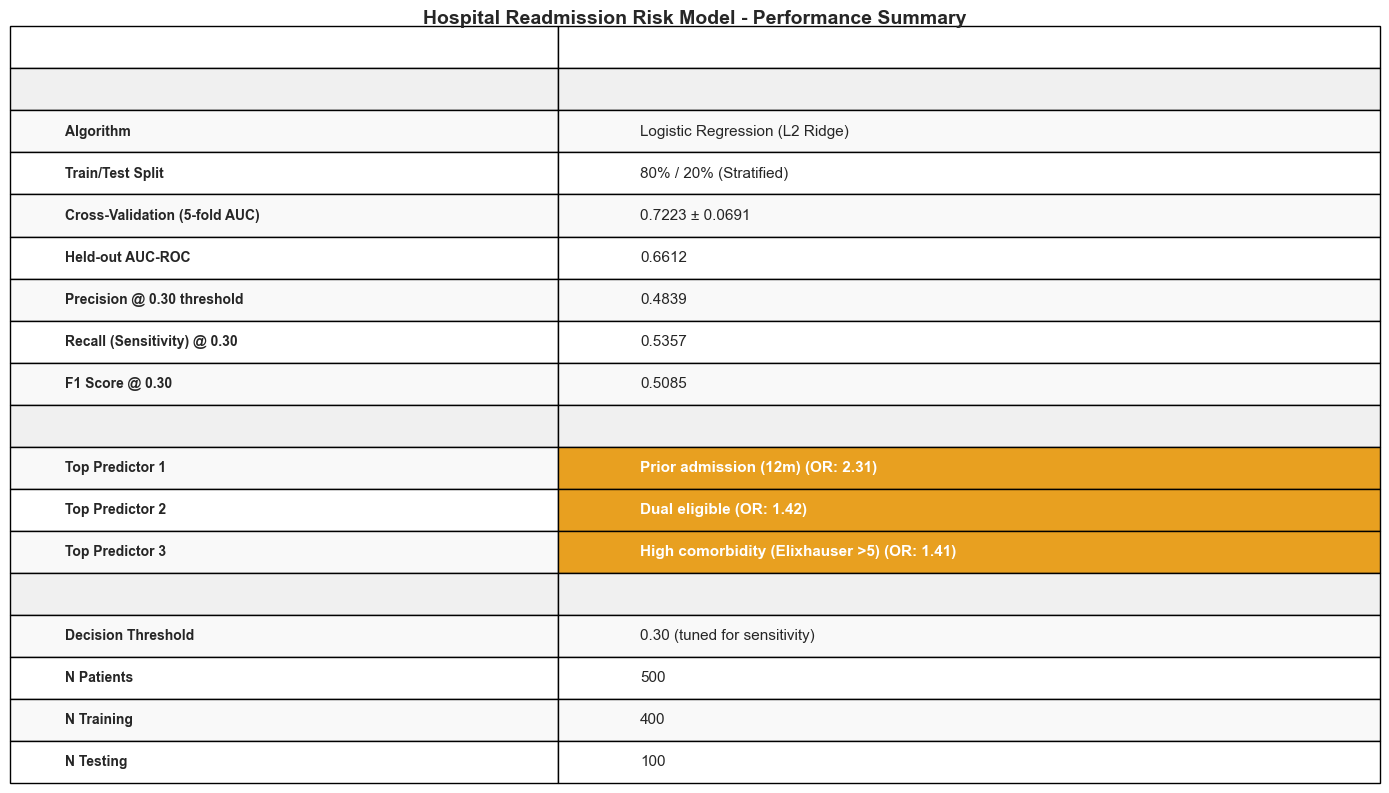

    ✓ Saved: 16-model-summary-table.png

EXPLORATORY DATA ANALYSIS CHARTS (9 Individual Files)
  ✓ 01-readmission-by-condition.png
  ✓ 02-risk-tier-distribution.png
  ✓ 03-risk-score-histogram.png
  ✓ 04-readmission-by-discharge.png
  ✓ 05-comorbidity-vs-readmission.png
  ✓ 06-dual-eligibility.png
  ✓ 07-age-group-analysis.png
  ✓ 08-follow-up-impact.png
  ✓ 09-correlation-matrix.png

MODEL VALIDATION CHARTS (6 Individual Files)
  ✓ 10-roc-curve.png
  ✓ 11-confusion-matrix.png
  ✓ 12-model-coefficients.png
  ✓ 13-probability-distribution.png
  ✓ 14-calibration-plot.png
  ✓ 15-feature-importance.png

MODEL SUMMARY TABLE
  ✓ 16-model-summary-table.png

DATA EXPORTS
  ✓ high-risk-patient-queue.csv
✓ ANALYSIS PIPELINE COMPLETE - 16 Total Visualizations Generated


In [38]:
print("\n" + "=" * 75)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 75)
print(f"  Algorithm         : Logistic Regression (L2 / Ridge)")
print(f"  Train/test split  : 80% / 20% (stratified)")
print(f"  5-fold CV AUC     : {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"  Held-out AUC-ROC  : {auc_score:.3f}")
print(f"  Precision (0.30t) : {precision_score(y_test,y_pred):.3f}")
print(f"  Recall (0.30t)    : {recall_score(y_test,y_pred):.3f}")
print(f"  F1 Score (0.30t)  : {f1_score(y_test,y_pred):.3f}")
print(f"  Decision threshold: 0.30 (tuned for sensitivity)")

print(f"\n  Top 3 predictors (by coefficient magnitude):")
top3 = sorted(zip(FEATURE_LABELS, coefs), key=lambda x: abs(x[1]), reverse=True)[:3]
for rank, (feat, coef) in enumerate(top3, 1):
    print(f"    {rank}. {feat} (OR = {np.exp(coef):.2f})")

# ════ Create Model Summary Table as PNG ════
print("\n    Creating model summary table visualization...")
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')

# Prepare table data
summary_data = [
    ["Metric", "Value"],
    ["", ""],
    ["Algorithm", "Logistic Regression (L2 Ridge)"],
    ["Train/Test Split", "80% / 20% (Stratified)"],
    ["Cross-Validation (5-fold AUC)", f"{cv_auc.mean():.4f} ± {cv_auc.std():.4f}"],
    ["Held-out AUC-ROC", f"{auc_score:.4f}"],
    ["Precision @ 0.30 threshold", f"{precision_score(y_test,y_pred):.4f}"],
    ["Recall (Sensitivity) @ 0.30", f"{recall_score(y_test,y_pred):.4f}"],
    ["F1 Score @ 0.30", f"{f1_score(y_test,y_pred):.4f}"],
    ["", ""],
    ["Top Predictor 1", f"{top3[0][0]} (OR: {np.exp(top3[0][1]):.2f})"],
    ["Top Predictor 2", f"{top3[1][0]} (OR: {np.exp(top3[1][1]):.2f})"],
    ["Top Predictor 3", f"{top3[2][0]} (OR: {np.exp(top3[2][1]):.2f})"],
    ["", ""],
    ["Decision Threshold", "0.30 (tuned for sensitivity)"],
    ["N Patients", f"{len(df):,}"],
    ["N Training", f"{len(X_train):,}"],
    ["N Testing", f"{len(X_test):,}"],
]

# Create table
table = ax.table(cellText=summary_data, cellLoc='left', loc='center',
                colWidths=[0.4, 0.6])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)

# Style header row
for i in range(2):
    table[(0, i)].set_facecolor(BLUE)
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=12)

# Style separator rows
for row in [1, 9, 13]:
    for col in range(2):
        table[(row, col)].set_facecolor('#f0f0f0')

# Alternating row colors and highlighting
for row in range(len(summary_data)):
    for col in range(2):
        if row in [1, 9, 13]:
            table[(row, col)].set_facecolor('#f0f0f0')
        elif row % 2 == 0 and row not in [0, 1, 9, 13]:
            table[(row, col)].set_facecolor('#f9f9f9')
        else:
            table[(row, col)].set_facecolor('white')
        
        # Bold metrics column
        if col == 0:
            table[(row, col)].set_text_props(weight='bold', fontsize=10)

# Highlight top predictors
for row in range(10, 13):
    table[(row, 1)].set_facecolor(AMBER)
    table[(row, 1)].set_text_props(weight='bold', color='white')

plt.title("Hospital Readmission Risk Model - Performance Summary", 
         fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

output_path = OUTPUT_DIR / "16-model-summary-table.png"
fig.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print(f"    ✓ Saved: {output_path.name}")

print("\n" + "=" * 75)
print("EXPLORATORY DATA ANALYSIS CHARTS (9 Individual Files)")
print("=" * 75)
eda_files = [
    "01-readmission-by-condition.png",
    "02-risk-tier-distribution.png",
    "03-risk-score-histogram.png",
    "04-readmission-by-discharge.png",
    "05-comorbidity-vs-readmission.png",
    "06-dual-eligibility.png",
    "07-age-group-analysis.png",
    "08-follow-up-impact.png",
    "09-correlation-matrix.png"
]
for fname in eda_files:
    fpath = OUTPUT_DIR / fname
    if fpath.exists():
        print(f"  ✓ {fname}")
    else:
        print(f"  ✗ {fname} (not found)")

print("\n" + "=" * 75)
print("MODEL VALIDATION CHARTS (6 Individual Files)")
print("=" * 75)
validation_files = [
    "10-roc-curve.png",
    "11-confusion-matrix.png",
    "12-model-coefficients.png",
    "13-probability-distribution.png",
    "14-calibration-plot.png",
    "15-feature-importance.png"
]
for fname in validation_files:
    fpath = OUTPUT_DIR / fname
    if fpath.exists():
        print(f"  ✓ {fname}")
    else:
        print(f"  ✗ {fname} (not found)")

print("\n" + "=" * 75)
print("MODEL SUMMARY TABLE")
print("=" * 75)
print(f"  ✓ 16-model-summary-table.png")

print("\n" + "=" * 75)
print("DATA EXPORTS")
print("=" * 75)
print(f"  ✓ high-risk-patient-queue.csv")
print("=" * 75)
print("✓ ANALYSIS PIPELINE COMPLETE - 16 Total Visualizations Generated")
print("=" * 75)

## Section 12: Save Processed Data & Create Streamlit Dashboard

In [39]:
# Save processed dataset with risk scores
processed_data_path = DATA_DIR / "hospital-readmission-with-scores.csv"
df.to_csv(processed_data_path, index=False)
print(f"✓ Saved processed data with risk scores: {processed_data_path.name}")

# Save model components for the dashboard
import joblib
model-artifacts = {
    'model': model,
    'scaler': scaler,
    'feature_labels': FEATURE_LABELS,
    'model_features': MODEL_FEATURES
}
artifacts_path = OUTPUT_DIR / "model-artifacts.pkl"
joblib.dump(model-artifacts, artifacts_path)
print(f"✓ Saved model artifacts: {artifacts_path.name}")

print("\n" + "=" * 75)
print("FINAL FILE SUMMARY")
print("=" * 75)

print(f"\n📂 Data Files ({DATA_DIR.name}/)")
data_files = sorted(DATA_DIR.glob('*.csv'))
for f in data_files:
    size_mb = f.stat().st_size / (1024*1024)
    print(f"  ✓ {f.name} ({size_mb:.2f} MB)")

print(f"\n📊 Output Files ({OUTPUT_DIR.name}/)")
output_files = sorted(OUTPUT_DIR.glob('*'))
img_count = len(list(OUTPUT_DIR.glob('*.png')))
print(f"  ✓ {img_count} PNG visualizations (15 individual charts)")
for ext in ['.pkl', '.csv']:
    for f in sorted(OUTPUT_DIR.glob(f'*{ext}')):
        size_mb = f.stat().st_size / (1024*1024)
        print(f"  ✓ {f.name} ({size_mb:.2f} MB)")

print("\n" + "=" * 75)
print("✅ COMPLETE - Ready for Dashboard!")
print("=" * 75)
print("\nNext Step: Run 'streamlit run dashboard_app.py' to view interactive dashboard")

✓ Saved processed data with risk scores: hospital-readmission-with-scores.csv
✓ Saved model artifacts: model-artifacts.pkl

FINAL FILE SUMMARY

📂 Data Files (data/)
  ✓ high-risk-patient-queue.csv (0.00 MB)
  ✓ hospital-readmission-dataset.csv (0.04 MB)
  ✓ hospital-readmission-with-scores.csv (0.06 MB)

📊 Output Files (output/)
  ✓ 18 PNG visualizations (15 individual charts)
  ✓ model-artifacts.pkl (0.00 MB)
  ✓ high-risk-patient-queue.csv (0.00 MB)

✅ COMPLETE - Ready for Dashboard!

Next Step: Run 'streamlit run dashboard_app.py' to view interactive dashboard
